# How to Access GES DISC Kerchunk Files

### Updated: 5/29/2026

### Overview

This Jupyter Notebook demonstrates how to access GPM_L3 and MERRA-2 “Kerchunk” files, a format for dataset virtualization. It shows the use of the Earthdata Login widget to authenticate with Earthdata Login servers, access a single M2T1NXSLV.5.12.4 Kerchunk file to demonstrate 2-meter temperature over Los Angeles during January 2010, and access and concatenate two GPM_IMERGDF Kerchunk files to plot MWPrecipitation values over Chicago during the 2011 Groundhog Day Blizzard and the corresponding "baseline" period in the previous year.

### Prerequisites

<div style="background:#FFFFC5; border:1px solid #000000; padding:5px 10px; color:#000000;">
    <strong>Note:</strong> The performance of this notebook depends on the number of CPU cores, available memory, and internet bandwidth of the compute instance.<br />
    If a query exceeds these resources, performance may be significantly degraded. In such cases, an alternative subsetting approach such as
    <a href="https://github.com/nasa/gesdisc-tutorials/blob/main/notebooks/How_to_Search_and_Load_Cloud_OPeNDAP.ipynb" target="_blank">Cloud OPeNDAP</a>
    or the
    <a href="https://github.com/nasa/gesdisc-tutorials/blob/main/notebooks/How_to_Subset_and_Download_L234_Data_Using_Python.ipynb" target="_blank">GES DISC Subsetter API</a>
    should be considered.
</div>

This notebook requires Python >=3.12 and the following libraries:

- Valid Earthdata Login credentials
- [xarray](https://docs.xarray.dev/en/stable/) (must be >=2025.4.0)
- [earthaccess](https://earthaccess.readthedocs.io/en/latest/quick-start/) (must be >=0.16)
- [terra_ui_components](https://github.com/nasa/terra-ui-components)
- [Pandas](https://pandas.pydata.org/) (must be <3.x)
- [Pyarrow](https://arrow.apache.org/docs/python/index.html) (must be exactly 23.0.1)
- [fsspec](https://filesystem-spec.readthedocs.io/en/latest/)
- [Zarr](https://zarr.readthedocs.io/en/stable/)
- [Dask.distributed](https://distributed.dask.org/en/stable/)
- [Matplotlib](https://matplotlib.org/)
- [Kerchunk](https://fsspec.github.io/kerchunk/)
- [Fastparquet](https://fastparquet.readthedocs.io/en/latest/) (must be exactly 2026.3.0)
- [s3fs](https://s3fs.readthedocs.io/en/latest/)
- [h5py](https://docs.h5py.org/en/stable/)
- [Virtualizarr](https://virtualizarr.readthedocs.io/en/stable/)


### Recommended Anaconda Environment YAML:
We ***strongly*** recommend installing the ['nasa-gesdisc-kerchunk' YAML file](https://github.com/nasa/gesdisc-tutorials/tree/main/environments/nasa-gesdisc-kerchunk.yml) provided in the 'environments' subfolder to run this notebook. 
Please follow the instructions [here](https://conda.io/projects/conda/en/latest/user-guide/tasks/manage-environments.html#creating-an-environment-from-an-environment-yml-file) to install and activate this environment.

### Run This Notebook in Google Colab
You can run this tutorial in your browser using Colab:<br>

<a target="_blank" href="https://colab.research.google.com/github/nasa/gesdisc-tutorials/blob/main/notebooks/How_To_Access_GES_DISC_Kerchunk_Files.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

***Google Colab Users***: Uncomment the cell below and run to install the required libraries for this notebook

In [ ]:
#! pip install earthaccess dask[distributed] zarr fastparquet terra_ui_components

### 1. Import Libraries

In [ ]:
import warnings
import earthaccess
import xarray as xr
import dask
from dask.distributed import Client
from terra_ui_components import TerraEarthdataLogin
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

### 2. Create Dask Workers

Change the number of workers (`n_workers`) based on your CPU core count.

In [ ]:
client = Client(
    n_workers=8,
    threads_per_worker=1,
)

### 3. Authenticate and Create Virtual Dataset Loader Function

In [ ]:
# Authenticate using Earthdata Login Widget
auth = TerraEarthdataLogin()
display(auth)

# Create virtual dataset loader function
def get_vds(parq: str, chunks: dict={}, **kwargs):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=xr.SerializationWarning)
        return xr.open_dataset(
            "reference://",
            engine="zarr",
            chunks=chunks,
            backend_kwargs={
                "storage_options": {
                    "fo": str(parq),
                    "remote_protocol": "https",
                    "asynchronous": True,
                    "remote_options": {
                        "headers": {"Authorization": f'Bearer {auth.bearerToken}'},
                        "asynchronous": True,
                    }
                },
                "consolidated": True
            },
            **kwargs
        )

### 4. Load a Single MERRA-2 Kerchunk File

Here, we will load a single Kerchunk file of M2T1NXSLV.5.12.4 for 2010. Note that this will only take a few seconds to run, since we have only loaded the metadata of the virtualized chunks. No actual data is loaded until we run Xarray compute functions in later cells.

A list of available collections and instructions to format a different Kerchunk URL can be found here: https://github.com/nasa/gesdisc-tutorials/blob/virtualizarr-tutorials-guidance/user-guidance/TDS_to_VDS.md

In [ ]:
vds = get_vds("https://data.gesdisc.earthdata.nasa.gov/browse/kerchunk/MERRA2/M2T1NXSLV.5.12.4/2010.parq")
print(vds)

<xarray.Dataset> Size: 685GB
Dimensions:   (time: 8760, lat: 361, lon: 576)
Coordinates:
  * time      (time) datetime64[ns] 70kB 2010-01-01T00:30:00 ... 2010-12-31T2...
  * lat       (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
  * lon       (lon) float64 5kB -180.0 -179.4 -178.8 ... 178.1 178.8 179.4
Data variables: (12/47)
    CLDPRS    (time, lat, lon) float64 15GB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    CLDTMP    (time, lat, lon) float64 15GB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    DISPH     (time, lat, lon) float64 15GB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    H1000     (time, lat, lon) float64 15GB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    H250      (time, lat, lon) float64 15GB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    H500      (time, lat, lon) float64 15GB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    ...        ...
    V250      (time, lat, lon) float64 15GB dask.array<c

### 5. Create Time Series of Surface Temperature Over Los Angeles for January 2010

This cell may take some time to run since we actually manifest the virtualized data to our compute instance when we call `compute()`

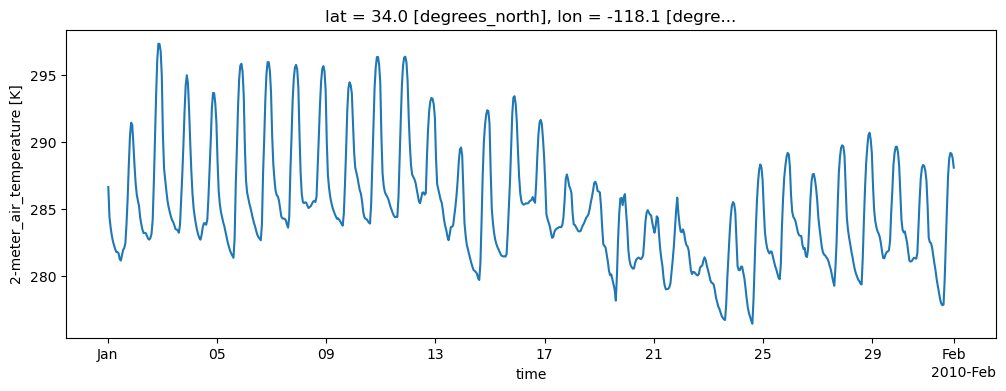

In [5]:
ts = vds['T2M'] \
    .sel(time=slice("2010-01-01","2010-01-31")) \
    .sel(lat=34.05, lon=-118.24, method="nearest") \
    .compute()

ts.plot(figsize=(12, 4))

### 6. Concatenate Two GPM_IMERGDF.07 Kerchunk Files

The `xr.concat` function can be used to concatenate two virtual dataset objects into a single virtual dataset. Here, we load GPM_IMERGDF.07 data from 2010-01-01 to 2011-12-31 and concatenate along the `time` dimension.

We will need to manually update the `BeginDate` and `EndDate` attributes to show the correct temporal length of the virtual dataset.

In [14]:
vds_1 = get_vds("https://data.gesdisc.earthdata.nasa.gov/browse/kerchunk/GPM_L3/GPM_3IMERGDF.07/2010.parq")
vds_2 = get_vds("https://data.gesdisc.earthdata.nasa.gov/browse/kerchunk/GPM_L3/GPM_3IMERGDF.07/2011.parq")

vds_concat = xr.concat([vds_1, vds_2], dim="time")
vds_concat.attrs["BeginDate"] = str(vds_concat.time.min().dt.date.values)
vds_concat.attrs["EndDate"] = str(vds_concat.time.max().dt.date.values)
print(vds_concat)

<xarray.Dataset> Size: 170GB
Dimensions:                         (time: 730, lon: 3600, lat: 1800, nv: 2)
Coordinates:
  * time                            (time) datetime64[ns] 6kB 2010-01-01 ... ...
  * lon                             (lon) float32 14kB -179.9 -179.9 ... 179.9
  * lat                             (lat) float64 14kB -89.95 -89.85 ... 89.95
Dimensions without coordinates: nv
Data variables:
    MWprecipitation                 (time, lon, lat) float32 19GB dask.array<chunksize=(1, 3600, 900), meta=np.ndarray>
    MWprecipitation_cnt             (time, lon, lat) float32 19GB dask.array<chunksize=(1, 3600, 900), meta=np.ndarray>
    MWprecipitation_cnt_cond        (time, lon, lat) float32 19GB dask.array<chunksize=(1, 3600, 900), meta=np.ndarray>
    precipitation                   (time, lon, lat) float32 19GB dask.array<chunksize=(1, 3600, 900), meta=np.ndarray>
    precipitation_cnt               (time, lon, lat) float32 19GB dask.array<chunksize=(1, 3600, 900), meta=np.

### 7. Query a Single Point over Los Angeles and Resample Daily Averaged Accumulation Rates

We will select the nearest point over Los Angeles, the `MWprecipitation` variable, and the period from 01-28 to 02-05 for both 2010 and 2011. Finally, we will convert to a daily, averaged accumulation rates to account for any noise in the data.

In [ ]:
lat = 41.87
lon = -87.62

point = vds_concat["MWprecipitation"].sel(
    lat=lat,
    lon=lon,
    method="nearest"
)

blizzard_2011 = point.sel(time=slice("2011-01-28", "2011-02-05"))
baseline_2010 = point.sel(time=slice("2010-01-28", "2010-02-05"))

# Convert to daily accumulation rates
blizzard_daily_2011 = blizzard_2011.resample(time="1D").mean() * 24
baseline_daily_2010 = baseline_2010.resample(time="1D").mean() * 24

### 8. Calculate Event Summary

The means, maxima, and minima are calculated below.

In [22]:
stats = {
    "2011_Blizzard_mean_mm_per_hr": float(blizzard_2011.mean()),
    "2010_Baseline_mean_mm_per_hr": float(baseline_2010.mean()),
    "2011_Blizzard_peak_mm_per_hr": float(blizzard_2011.max()),
    "2010_Baseline_peak_mm_per_hr": float(baseline_2010.max()),
    "2011_Blizzard_total_mm": float(blizzard_daily_2011.sum()),
    "2010_Baseline_total_mm": float(baseline_daily_2010.sum()),
}

print("\nEvent Summary:")
for k, v in stats.items():
    print(f"{k}: {v:.3f}")


Event Summary:
2011_Blizzard_mean_mm_per_hr: 0.302
2010_Baseline_mean_mm_per_hr: 0.056
2011_Blizzard_peak_mm_per_hr: 1.091
2010_Baseline_peak_mm_per_hr: 0.240
2011_Blizzard_total_mm: 65.178
2010_Baseline_total_mm: 12.053


### 9 Compare Daily Average Precipitation Totals by Day of Year

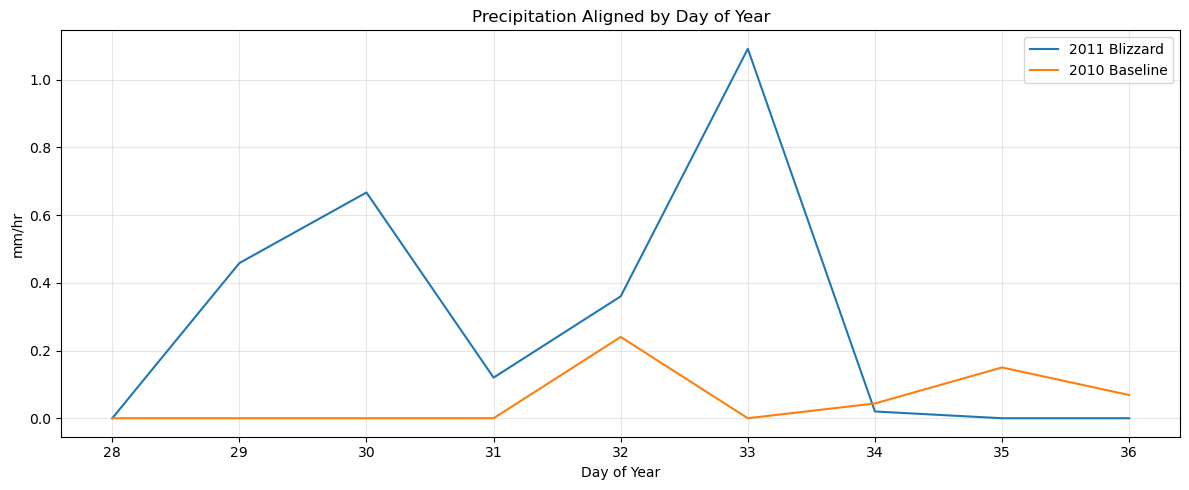

In [ ]:
# Convert to pandas index
t1 = pd.to_datetime(blizzard_2011.time.values)
t2 = pd.to_datetime(baseline_2010.time.values)

# Day of year (1–365/366)
x1 = t1.dayofyear
x2 = t2.dayofyear

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(x1, blizzard_2011.values,
        label="2011 Blizzard", linewidth=1.5)

ax.plot(x2, baseline_2010.values,
        label="2010 Baseline", linewidth=1.5)

ax.set_title("Precipitation Aligned by Day of Year")
ax.set_xlabel("Day of Year")
ax.set_ylabel("mm/hr")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()